# Task 1: Superstore Data Analysis
Report on the revenue of a Superstore or sometthing....


In [150]:
import pandas as pd
from IPython.display import Markdown, display

df = pd.read_csv("SuperstoreDataSample.csv", encoding="cp1252")

## Data Inspection
Understanding the data

### The available heads of the data:

In [151]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit;'],
      dtype='str')

The Profit header seems to be the only header which requires cleaning.

### Information about Columns

The the number of non-null values, data types of each column and memory usage of the DataFrame. 

In [152]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   str    
 1   Order ID       7484 non-null   str    
 2   Order Date     7484 non-null   str    
 3   Ship Date      7484 non-null   str    
 4   Ship Mode      7484 non-null   str    
 5   Customer ID    7484 non-null   str    
 6   Customer Name  7484 non-null   str    
 7   Segment        7484 non-null   str    
 8   Country        7484 non-null   str    
 9   City           7484 non-null   str    
 10  State          7484 non-null   str    
 11  Postal Code    7484 non-null   float64
 12  Region         7484 non-null   str    
 13  Product ID     7484 non-null   str    
 14  Category       7484 non-null   str    
 15  Sub-Category   7484 non-null   str    
 16  Product Name   7484 non-null   str    
 17  Sales          7484 non-null   float64
 18  Quantity       7484

This is useful for understanding the structure of our data and identifying any potential issues with missing values or incorrect data types.

Notable issues:

    -Incorrect date formats
    -Incorrect Profit data type

### Amount of Null values

In [153]:
df.isnull().sum()

Row ID              0
Order ID         2510
Order Date       2510
Ship Date        2510
Ship Mode        2510
Customer ID      2510
Customer Name    2510
Segment          2510
Country          2510
City             2510
State            2510
Postal Code      2510
Region           2510
Product ID       2510
Category         2510
Sub-Category     2510
Product Name     2510
Sales            2510
Quantity         2510
Discount         2510
Profit;          2510
dtype: int64

These are rows to be filtered out

### Data Description

    Summary statistics for the numerical columns in our DataFrame, such as count, mean, standard deviation, minimum, and maximum values. 
    This helps us get a quick overview of the distribution and central tendencies of our numerical data.

In [154]:
df.describe()

,Postal Code,Sales,Quantity,Discount
count,7484.000000,7484.000000,7484.000000,7484.000000
mean,55587.591529,246.987420,3.776991,0.154969
std,31990.451627,674.440108,2.212994,0.205513
min,1040.000000,0.444000,1.000000,0.000000
25%,23602.000000,16.272000,2.000000,0.000000
50%,60035.000000,54.580000,3.000000,0.200000
75%,90008.000000,223.920000,5.000000,0.200000
max,99301.000000,22638.480000,14.000000,0.800000


# Data cleaning

### Dropping missing values

In [155]:
df = df.dropna()
#df.isnull().sum()

Empty rows have successfully been removed.

### Formatting Profits

In [156]:
df.rename(columns={'Profit;': 'Profit'}, inplace=True)
print("The profit column name is: Profit")

print(df.loc[0:4, 'Profit'])
df['Profit'] = df['Profit'].str.replace(';', '')
df['Profit']= df['Profit'].astype(float)
print()
print("The profit column data type is: ", df['Profit'].dtype)
print(df.loc[0:4, 'Profit'])

The profit column name is: Profit
0     41.9136;
2      6.8714;
3    -383.031;
4      2.5164;
Name: Profit, dtype: str

The profit column data type is:  float64
0     41.9136
2      6.8714
3   -383.0310
4      2.5164
Name: Profit, dtype: float64


### Formatting Dates

In [157]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

---

# Data Analysis

## KPIs used

## Revenue Analysis

This section analyses the sales and profit made throughout the year and aims to give clear insights on the periods at which the business does well and the periods at which it does not.

### Anual Sales

Order Date
2014    394984.5790
2015    374186.0346
2016    476090.1966
2017    603193.0423
Name: Sales, dtype: float64


<Axes: title={'center': 'Anual Sales'}, xlabel='Order Date', ylabel='Sales'>

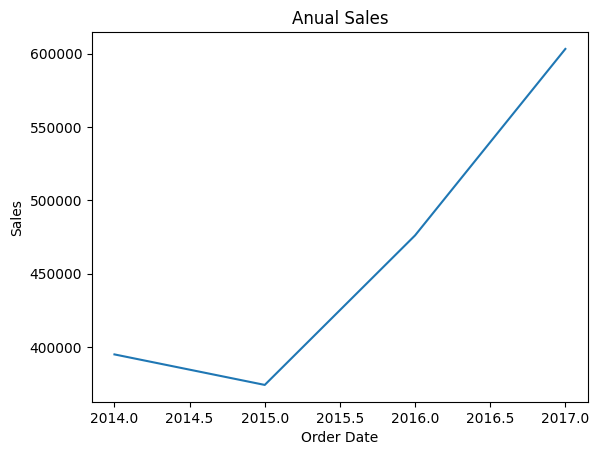

In [158]:
years = df['Order Date'].dt.year
sale_group_obj = df.groupby(years)
anual_sales = sale_group_obj['Sales'].sum()
print(anual_sales)
anual_sales.plot(kind='line', ylabel='Sales', title='Anual Sales')

    The graph indicates an increasing trend from 2015 to 2017. The turning point indicates business growth from the year 2015, indicating that the current measures being taken to ensure the success of the business are proving fruitfull.

    The rate of sales being made seems to have had a slight increase in the year 2016 till date, highlighting the effectiveness of the strategy to ensure business growth

### Monthly Sales

In [159]:
months = df['Order Date'].dt.month
sale_group_obj = df.groupby(months)
monthly_sales = sale_group_obj['Sales'].sum()
for month, sales in monthly_sales.items():
    print(f"Month {month:02d}: {sales:.2f}")

Month 01: 81338.11
Month 02: 39355.75
Month 03: 174336.52
Month 04: 107640.23
Month 05: 133014.80
Month 06: 119218.77
Month 07: 116307.54
Month 08: 136272.99
Month 09: 239506.17
Month 10: 160324.55
Month 11: 283324.20
Month 12: 257814.22


#### Monthly Sales Plot:

<Axes: title={'center': 'Monthly Sales'}, xlabel='Order Date', ylabel='Sales'>

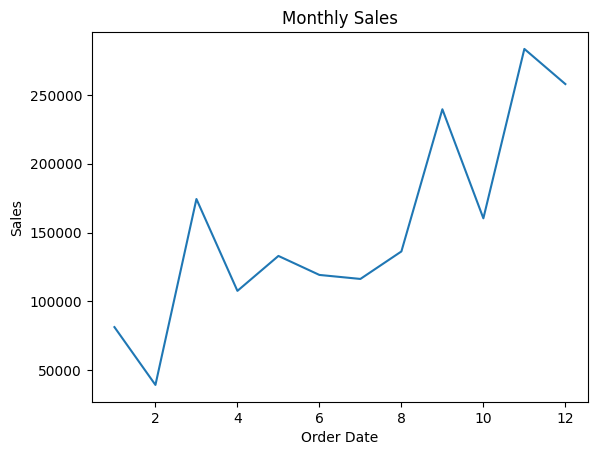

In [160]:
monthly_sales.plot(kind='line', ylabel='Sales', title='Monthly Sales')

The trend seems to decline in the first two months. Then, there's a drastic increase from February till March. It then fluctuates with a peak in September headed to a decline. Finally, from October till December, the trend remains high.

#### Early Year dip

It would be wise to Investigate and address the dip in the first two months.

A way to deal with this could be to have Post-Holiday promotions or pre-selling the products sold during spring.

#### Year-end peak

These are the months at which the business has to capitalize.

The peak in November indicates that strategy can be leveraged to maximize on the captailization of the November holidays.

## Regional Perfomance

### Overview

This section analyzes sales performance across 4 regions: West, East, Central, and South using Sales, Profit, and Profit Margin.


### Sales by Region

Region
West       595400.5800
East       523368.9800
Central    411913.2230
South      317771.0695
Name: Sales, dtype: float64


<Axes: title={'center': 'Regional Sales'}, xlabel='Regions', ylabel='Sales (USD)'>

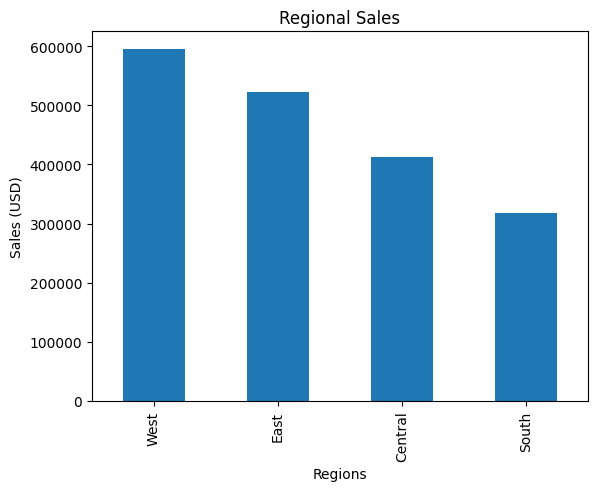

In [161]:
region_group_obj = df.groupby('Region')
region_sales = region_group_obj['Sales'].sum().sort_values(ascending=False)
print(region_sales)
region_sales.plot(kind='bar', xlabel= 'Regions', ylabel='Sales (USD)', title='Regional Sales')

The western regions generates 87% more than the southern region, indicating a significant market imbalance. This suggests that the South may have less demand or be under resourced since there is less engagement.

### Profits by Regions

Region
West       91416.0814
East       77069.6024
Central    38877.7150
South      35121.6874
Name: Profit, dtype: float64


<Axes: title={'center': 'Regional Profits'}, xlabel='Regions', ylabel='Profit (USD)'>

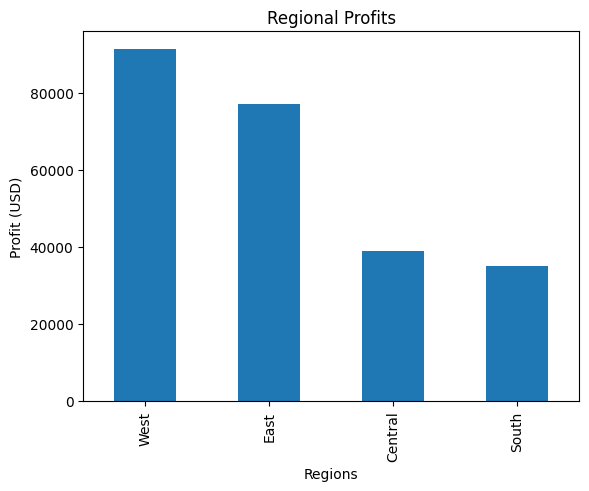

In [162]:
profit_group_obj = df.groupby('Region')
profit_group = profit_group_obj['Profit'].sum().sort_values(ascending=False)

print(profit_group)
profit_group.plot(kind='bar', xlabel= 'Regions', ylabel='Profit (USD)', title='Regional Profits')

    The western region leads in profit too ($91k), maintaining consistent performance.
    The central regions "shows a red flag" with approximately ($412k) in sales but roughly ($38.9k) in profit, signifying a very low return.
    The south, despite its low sales ($317k), seems to generate profit ($35k) close to that of the central, indicating better efficiency.

### Profit margins

West: 15.35 %
East: 14.73 %
Central: 9.44 %
South: 11.05 %


<Axes: title={'center': 'Regional Profit Margin'}, xlabel='Regions', ylabel='Profit Margin (%)'>

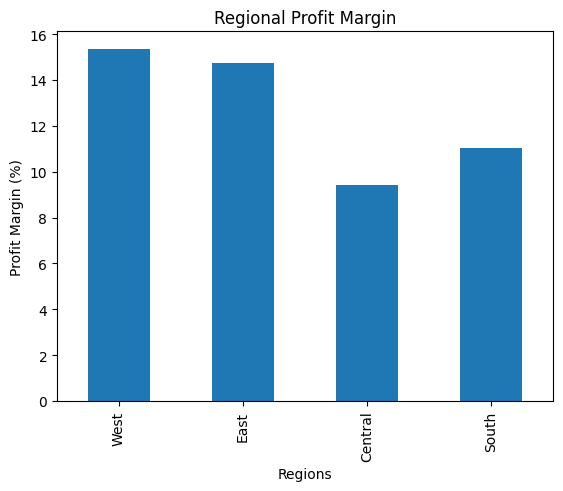

In [163]:
profit_margin = (profit_group / region_sales) * 100
for region, profit in profit_margin.items():
    print(f"{region}: {profit:.2f} %")

profit_margin.plot(kind='bar', xlabel= 'Regions', ylabel='Profit Margin (%)', title='Regional Profit Margin')

***Give (a) recommendation(s) like "Review Central's top 10 products for discount rates >15% and renegotiate supplier costs to improve margin to 12% within 2 quarters."***

In [164]:
print(profit_margin.mean())

12.642555546824493


## Categories

Category
Technology         789020.6400
Office Supplies    580847.7300
Furniture          478585.4825
Name: Sales, dtype: float64


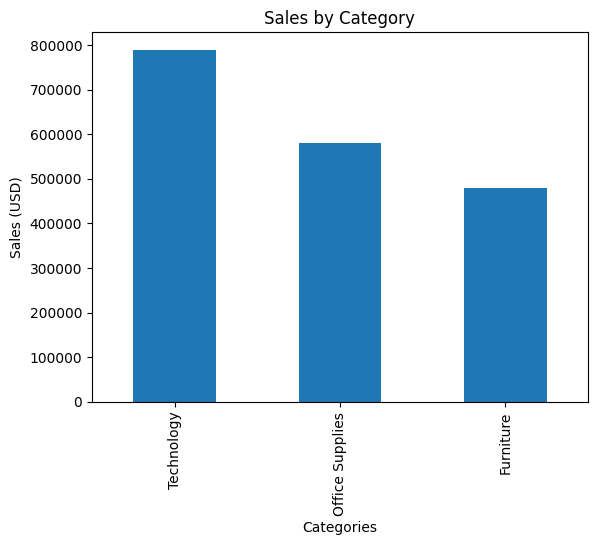

In [165]:
categories_grp_obj = df.groupby('Category')
sales_by_category = categories_grp_obj['Sales'].sum().sort_values(ascending=False)
print(sales_by_category)
sales_by_category.plot(kind='bar', xlabel= 'Categories', ylabel='Sales (USD)', title='Sales by Category')
profit_by_category = categories_grp_obj['Profit'].sum().sort_values(ascending=False)

### Profits


Profit by Category:
Category
Technology         135977.9624
Office Supplies     97555.1085
Furniture            8952.0153
Name: Profit, dtype: float64


<Axes: title={'center': 'Profit by Category'}, xlabel='Categories', ylabel='Profit (USD)'>

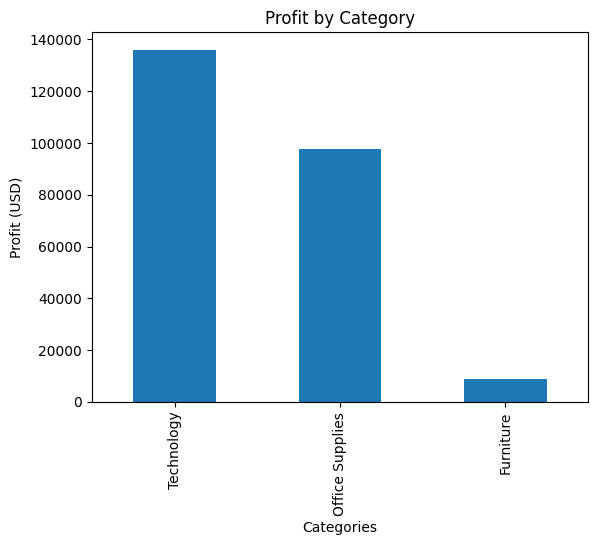

In [166]:
print()
print("Profit by Category:")
print(profit_by_category)
profit_by_category.plot(kind='bar', xlabel= 'Categories', ylabel='Profit (USD)', title='Profit by Category')

## Top-Selling Products

<Axes: title={'center': 'Product Sales'}, xlabel='Sales (USD)', ylabel='Products'>

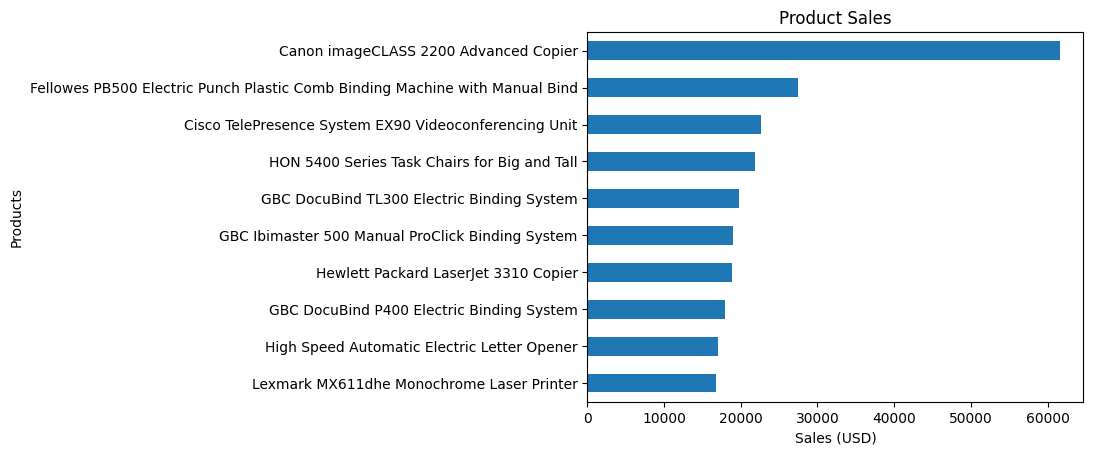

In [167]:
sale_group_obj = df.groupby('Product Name')
product_sales = sale_group_obj['Sales'].sum().sort_values(ascending=True).tail(10)
product_sales.plot(kind='barh', xlabel= 'Sales (USD)', ylabel='Products', title='Product Sales')

Product Name
Hewlett Packard 610 Color Digital Copier / Printer                              3124.9375
Honeywell Enviracaire Portable HEPA Air Cleaner for 17' x 22' Room              3247.0200
Zebra ZM400 Thermal Label Printer                                               3343.5360
Ibico EPK-21 Electric Binding System                                            3345.2823
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
Canon PC1060 Personal Laser Copier                                              4570.9347
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Name: Profit, dtype: float64


<Axes: title={'center': 'Product Profits'}, xlabel='Profit (USD)', ylabel='Products'>

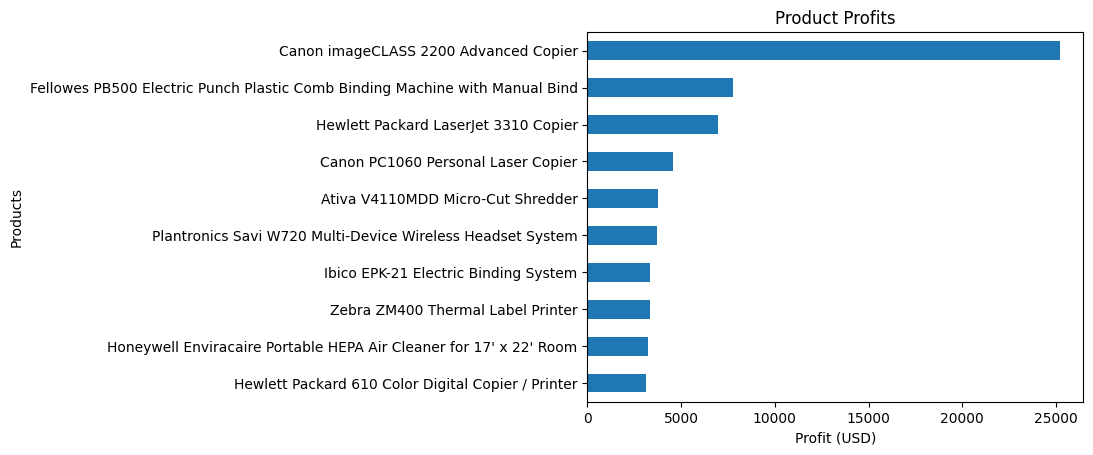

In [137]:
profit_group_obj = df.groupby('Product Name')
product_profits = profit_group_obj['Profit'].sum().sort_values(ascending=True).tail(10)
print(product_profits)
product_profits.plot(kind='barh', xlabel= 'Profit (USD)', ylabel='Products', title='Product Profits')

## Segments

### Sales

Segment
Consumer       936507.1928
Corporate      554778.0364
Home Office    357168.6233
Name: Sales, dtype: float64


<Axes: title={'center': 'Sales by Segment'}, xlabel='Segments', ylabel='Sales (USD)'>

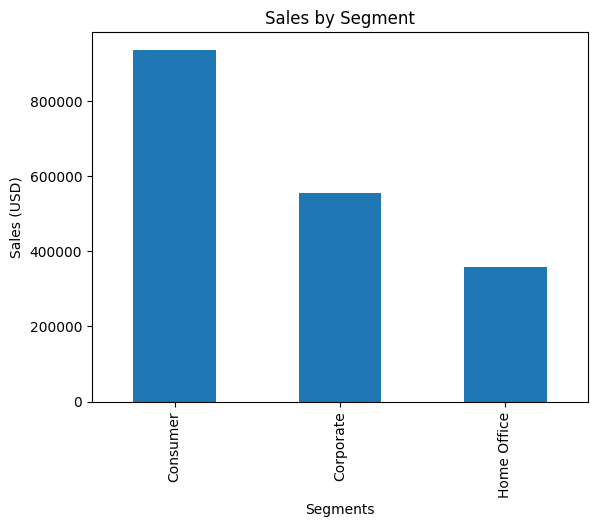

In [138]:
seg_grp_obj = df.groupby('Segment')
sales_by_segment = seg_grp_obj['Sales'].sum().sort_values(ascending=False)
print(sales_by_segment)
sales_by_segment.plot(kind='bar', xlabel= 'Segments', ylabel='Sales (USD)', title='Sales by Segment')


Profit by Segment:
Segment
Consumer       113252.3562
Corporate       74732.8464
Home Office     54499.8836
Name: Profit, dtype: float64


<Axes: title={'center': 'Profit by Segment'}, xlabel='Segments', ylabel='Profit (USD)'>

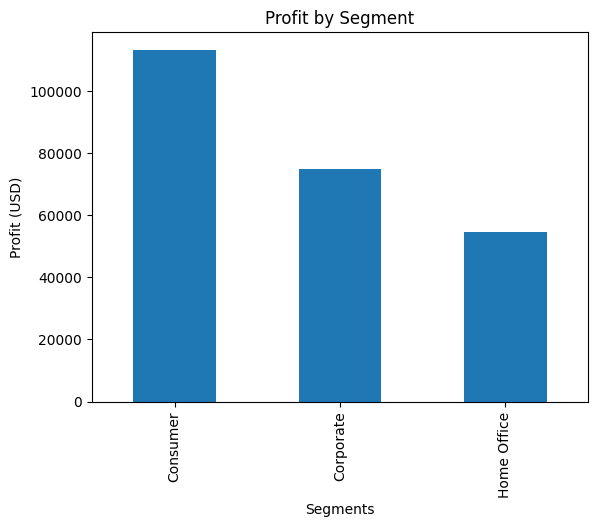

In [139]:
profit_by_segment = seg_grp_obj['Profit'].sum().sort_values(ascending=False)
print()
print("Profit by Segment:")
print(profit_by_segment)
profit_by_segment.plot(kind='bar', xlabel= 'Segments', ylabel='Profit (USD)', title='Profit by Segment')